# Introduction:
This project segments 2000 synthetic fintech customers into behavioral personas using unsupervised learning, since real transaction data at this granularity requires data-sharing agreements. The goal is not prediction but actionable customer groups a fintech product team could act on

## Step 0 : Importing Important Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## Step 1 : Synthethic Data Creation
Real open banking transaction data at this granularity isn't publicly available without formal
data-sharing agreements, so 4 customer personas (High Spender, Conservative Saver, Young Investor,
Bill Payer) are generated synthetically using `np.random.normal()`, with persona-specific means
and standard deviations across 6 spending features. Ground truth persona labels are kept aside
and used only for evaluation afterward — never fed into K-Means during fitting.

In [2]:
np.random.seed(42)

N_PER_PERSONA = 500

personas = {
    "high_spender": {
        "avg_txn_amount":     (3500, 800),
        "txn_frequency":      (45, 8),
        "retail_ratio":       (0.45, 0.08),
        "investment_ratio":   (0.05, 0.03),
        "bill_ratio":         (0.15, 0.05),
        "entertainment_ratio":(0.35, 0.08),
    },
    "conservative_saver": {
        "avg_txn_amount":     (600, 200),
        "txn_frequency":      (12, 4),
        "retail_ratio":       (0.15, 0.05),
        "investment_ratio":   (0.10, 0.05),
        "bill_ratio":         (0.55, 0.10),   #
        "entertainment_ratio":(0.10, 0.05),
    },
    "young_investor": {
        "avg_txn_amount":     (1500, 400),
        "txn_frequency":      (25, 6),
        "retail_ratio":       (0.20, 0.06),
        "investment_ratio":   (0.45, 0.10),
        "bill_ratio":         (0.15, 0.05),
        "entertainment_ratio":(0.15, 0.05),
    },
    "bill_payer": {
        "avg_txn_amount":     (2200, 500),
        "txn_frequency":      (10, 3),
        "retail_ratio":       (0.10, 0.04),
        "investment_ratio":   (0.05, 0.03),
        "bill_ratio":         (0.65, 0.10),
        "entertainment_ratio":(0.10, 0.04),
    },
}

feature_names = ["avg_txn_amount", "txn_frequency", "retail_ratio",
                  "investment_ratio", "bill_ratio", "entertainment_ratio"]

all_rows = []
for persona_name, params in personas.items():
    data = {}
    for feat in feature_names:
        mean, std = params[feat]
        data[feat] = np.random.normal(loc=mean, scale=std, size=N_PER_PERSONA)
    df_persona = pd.DataFrame(data)
    df_persona["persona"] = persona_name
    all_rows.append(df_persona)

df = pd.concat(all_rows, ignore_index=True)
df

,avg_txn_amount,txn_frequency,retail_ratio,investment_ratio,bill_ratio,entertainment_ratio,persona
0,3897.371322,52.409420,0.561948,0.073351,0.116241,0.395649,high_spender
1,3389.388559,60.275333,0.523971,0.033464,0.142774,0.427455,high_spender
2,4018.150830,33.811459,0.454770,0.025454,0.110379,0.323495,high_spender
3,4718.423885,49.503754,0.398245,0.049899,0.134602,0.301021,high_spender
4,3312.677300,39.794859,0.505858,0.044894,0.055319,0.263188,high_spender
...,...,...,...,...,...,...,...
1995,1595.282336,13.903306,0.089576,0.057242,0.644250,0.052752,bill_payer
1996,2821.413447,4.004965,0.040505,0.059758,0.602452,0.097087,bill_payer
1997,2563.583994,7.884050,0.103488,0.085378,0.583617,0.133521,bill_payer
1998,2232.945804,11.487297,0.149892,0.073734,0.625894,0.095972,bill_payer


In [3]:
print(df.shape)
print(df.describe())
print(df.info())
df.isna().sum()

(2000, 7)
       avg_txn_amount  txn_frequency  retail_ratio  investment_ratio  \
count     2000.000000    2000.000000   2000.000000       2000.000000   
mean      1947.208832      22.983037      0.226048          0.162928   
std       1180.133552      15.151859      0.151370          0.179579   
min         14.110262      -1.767201     -0.009617         -0.058835   
25%        917.975567      10.774480      0.115357          0.044576   
50%       1815.212676      17.068290      0.172999          0.078594   
75%       2715.143484      34.137494      0.316538          0.221156   
max       6582.185193      66.059057      0.658135          0.736521   

        bill_ratio  entertainment_ratio  
count  2000.000000          2000.000000  
mean      0.373209             0.175299  
std       0.239363             0.119127  
min      -0.041833            -0.044976  
25%       0.149461             0.092302  
50%       0.312006             0.137563  
75%       0.595065             0.229714  
max  

,0
avg_txn_amount,0
txn_frequency,0
retail_ratio,0
investment_ratio,0
bill_ratio,0
entertainment_ratio,0
persona,0


## Preprocessing
Data Created using Normal distribution may have negative ouliers which may be false for monetary features

In [4]:
df["avg_txn_amount"] = df["avg_txn_amount"].clip(lower=50)
df["txn_frequency"]  = df["txn_frequency"].clip(lower=1).round().astype(int)
ratio_cols = ["retail_ratio", "investment_ratio", "bill_ratio", "entertainment_ratio"]
df[ratio_cols] = df[ratio_cols].clip(lower=0, upper=1)
df[ratio_cols] = df[ratio_cols].div(df[ratio_cols].sum(axis=1), axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


(2000, 6)
persona
bill_payer            500
high_spender          500
young_investor        500
conservative_saver    500
Name: count, dtype: int64


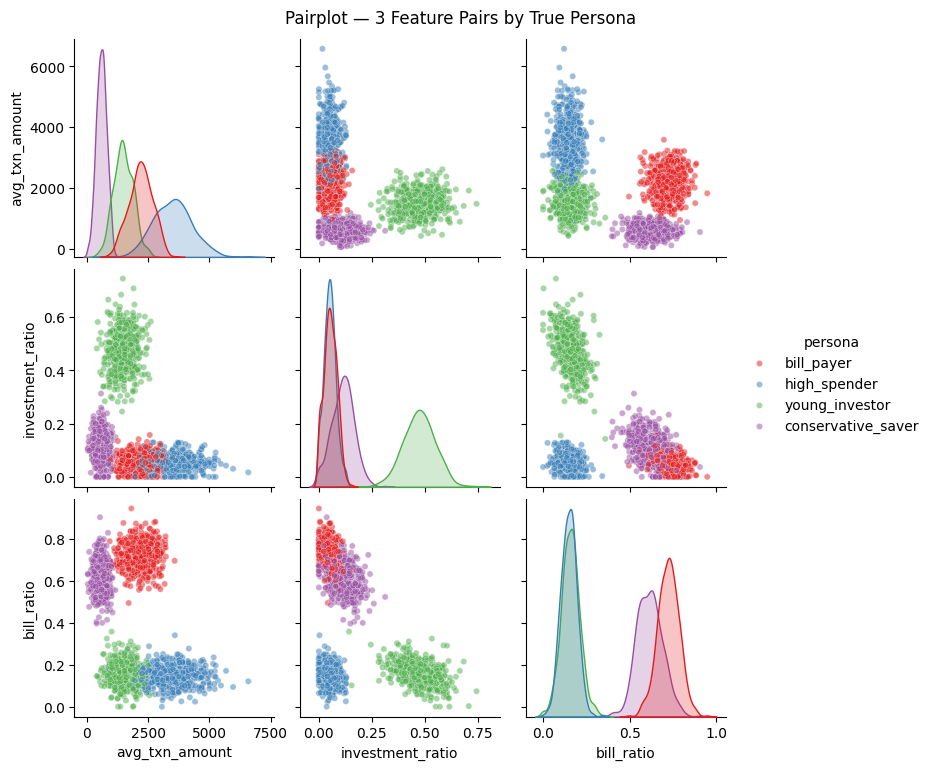

In [5]:
y_true = df["persona"].copy()
X = df.drop(columns=["persona"])

print(X.shape)
print(y_true.value_counts())

df_plot = X.copy()
df_plot["persona"] = y_true

sns.pairplot(
    df_plot,
    vars=["avg_txn_amount", "investment_ratio", "bill_ratio"],
    hue="persona",
    palette="Set1",
    plot_kws={"alpha": 0.5, "s": 20}
)
plt.suptitle("Pairplot — 3 Feature Pairs by True Persona", y=1.02)
plt.show()

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Selecting K Value
K-Means requires the number of clusters to be chosen in advance, unlike hierarchical clustering.
Two methods are checked together rather than relying on either alone: the elbow method (WCSS/
inertia) looks for the point where adding more clusters stops meaningfully reducing within-cluster
variance, and the silhouette score directly measures how well-separated and cohesive clusters are.
Agreement between both gives more confidence than trusting a single metric.

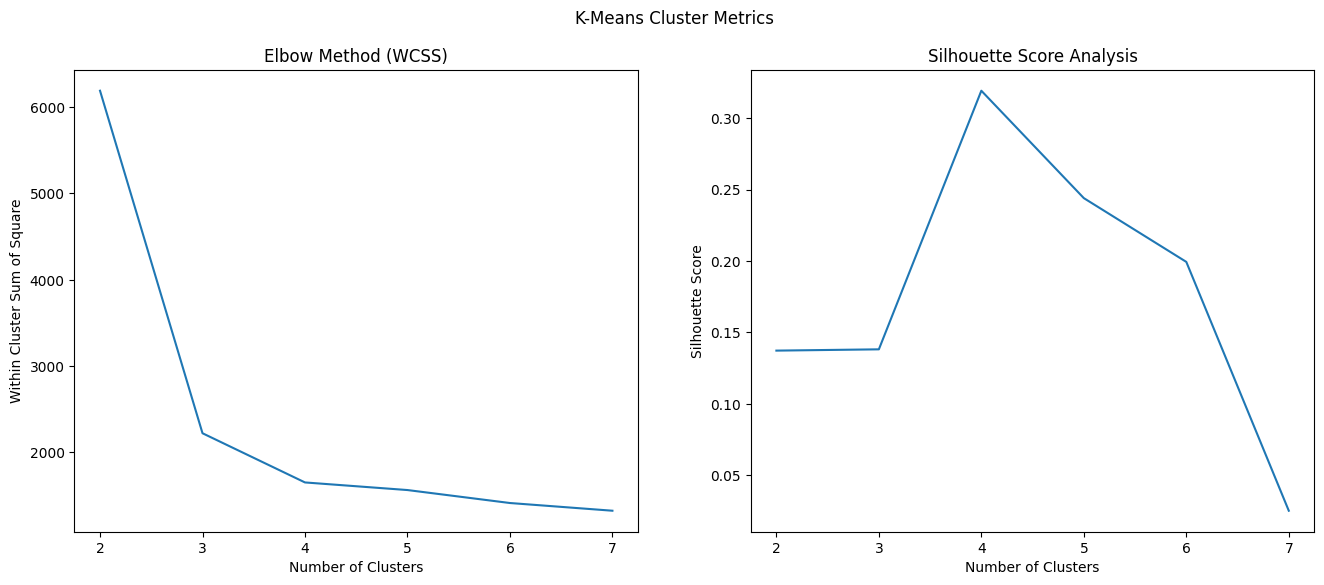

[6189.932893282238,
 2222.306802413912,
 1652.344540482428,
 1564.2275584611402,
 1414.0051722726414,
 1324.7670786700292]

[np.float64(0.13725959662344053),
 np.float64(0.1381584460839938),
 np.float64(0.31919389232457873),
 np.float64(0.24401030454659275),
 np.float64(0.19936878960907156),
 np.float64(0.02518024600611968)]

In [7]:
wcss = [] # Within Cluster Sum of Squares/Inertia
ss = [] # Silhouette score
for k in range(2,8):
  kmi = KMeans(n_clusters=k,random_state=42).fit(X_scaled)
  wcss.append(kmi.inertia_)
  ss.append(silhouette_score(X,kmi.labels_))

fig,ax = plt.subplots(1,2,figsize=(16,6))
plt.suptitle("K-Means Cluster Metrics")
sns.lineplot(x=np.arange(2,8),y=wcss,ax=ax[0])
ax[0].set_title("Elbow Method (WCSS)")
ax[0].set_xlabel("Number of Clusters")
ax[0].set_ylabel("Within Cluster Sum of Square")

sns.lineplot(x=np.arange(2,8),y=ss,ax=ax[1])
ax[1].set_title("Silhouette Score Analysis")
ax[1].set_xlabel("Number of Clusters")
ax[1].set_ylabel("Silhouette Score")
plt.show()
display(wcss)
ss


I chose k=4 because the elbow is at k=4 and the silhouette score peaks at k=4 (Although it is not the best it is the highest).

## K-Means Clustering
Fitting the final model with k=4, using `k-means++` initialization and a fixed `random_state` for reproducibility.

In [8]:
km1 = KMeans(n_clusters=4, init='k-means++', random_state=42).fit(X_scaled)
print(f"Within Cluster Sum of Squared: {km1.inertia_}")
print(f"Silhouette Score: {silhouette_score(X_scaled,km1.labels_)}")

Within Cluster Sum of Squared: 1652.344540482428
Silhouette Score: 0.526261389798564


## PCA 2D Visualisation
K-Means was fit on all 6 scaled features, which can't be visualized directly. PCA reduces the data
to 2 dimensions purely for visualization here — to sanity-check whether the clusters K-Means found
are visually distinguishable — not to change the clustering itself, which was already done above.

Total variance : 87.04%


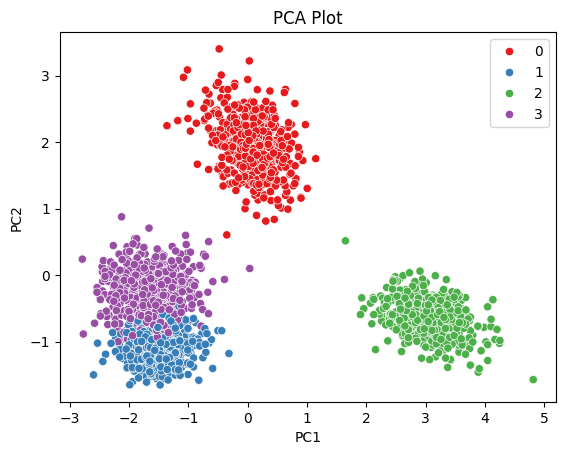

In [9]:
pc2d = PCA(n_components=2).fit(X_scaled)
X_transformed = pc2d.transform(X_scaled)
print(f"Total variance : {np.sum(pc2d.explained_variance_ratio_)*100:.2f}%")
sns.scatterplot(x=X_transformed[:,0],y=X_transformed[:,1],hue=km1.labels_,palette="Set1")
plt.title("PCA Plot")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Ok so 2D PCA has captured 87% of the data represented, when plotted 2 component, 2 clusters can be separated visually but between bill_payer and conservative_saver have visible overlap which may not be identified correctly

## PCA Cummulative Variance score with increasing number of Components
Beyond 2D visualization, this checks how many components are needed to retain most of the actual
variance in the data — relevant to the experiment below, where clustering is re-run on the
reduced-dimension data instead of the original 6 scaled features.

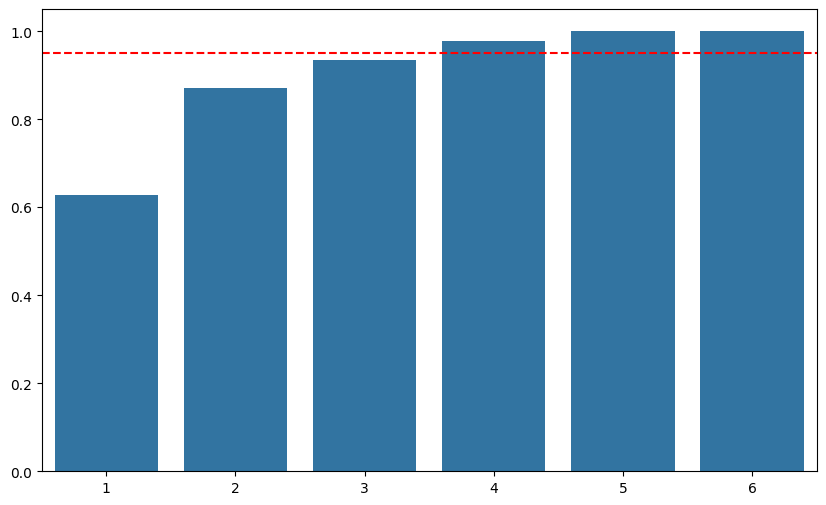

In [10]:
pcND = PCA().fit(X_scaled)
cummulative_variance_score = pcND.explained_variance_ratio_.cumsum()

fig,ax = plt.subplots(figsize=(10,6))
sns.barplot(x=np.arange(1,7),y=cummulative_variance_score)
ax.axhline(0.95,color='red',linestyle='--')
plt.show()

In [11]:
pc4D = PCA(n_components=4).fit(X_scaled)
X_4D = pc4D.transform(X_scaled)
km_4D = KMeans(n_clusters=4,random_state=42).fit(X_4D)
print(f"Within Cluster Sum of Square : {km_4D.inertia_}")
print(f"Silhouette Score :{silhouette_score(X_4D,km_4D.labels_)}")

Within Cluster Sum of Square : 1383.5808607562349
Silhouette Score :0.5601626305557204


## Choosing Between Raw-Feature and PCA-Reduced K-Means

Two K-Means models are compared at k=4: one fit directly on the 6 scaled features (`km1`), and
one fit on the top-4 PCA components (`km_4D`), which together retain ~95% of total variance.
The PCA-reduced version achieves a higher silhouette score (0.56 vs 0.52) — likely because
compressing to the highest-variance components removes some noise/redundancy across the
correlated ratio features, making clusters slightly more separable. `km_4D` is used as the
final model for profiling and business insights below.

In [12]:
df_profile = X.copy()
df_profile['cluster'] = km_4D.labels_
df_profile['cluster'].value_counts()

,count
cluster,
3,518
2,501
0,498
1,483


## Cluster Profiling
Profiling new clustering as per new labels and evaluating which cluster do they represent by comparing with synthetic data

In [13]:
cluster_means = df_profile.groupby('cluster').mean()
cluster_means

,avg_txn_amount,txn_frequency,retail_ratio,investment_ratio,bill_ratio,entertainment_ratio
cluster,,,,,,
0,1492.428668,24.801205,0.209166,0.474253,0.157381,0.159201
1,2230.819843,9.917184,0.110680,0.053382,0.723754,0.112184
2,3500.457274,45.249501,0.453990,0.051414,0.147919,0.346678
3,617.870322,11.928571,0.162598,0.111345,0.617131,0.108926


|Cluster label|Cluster Name (As per synthetic data)|
|--|--|
|0|Young Investor|
|1|High Spender|
|2|Bill Payer|
|3|Conservative Saver|

**Cluster 1 = High Spenders** — highest avg_txn_amount (₹3500) and highest txn_frequency (45/month),
spend concentrated in retail (0.45) and entertainment (0.35). Matches a customer who transacts
often and spends heavily on lifestyle categories.

**Cluster 0 = Young Investors** — investment_ratio (0.47) is far above every other cluster —
nearly half of spend goes to SIPs/investments, with moderate avg_txn_amount (₹1492) and frequency
(24.8/month). This is the single clearest signal of any cluster.

**Cluster 2 = Bill Payers** — bill_ratio is highest of all clusters (0.72), combined with the
lowest txn_frequency (9.9/month) — few transactions, but most of what exists is EMIs/bills, not
day-to-day spending.

**Cluster 3 = Conservative Savers** — lowest avg_txn_amount by a wide margin (₹621, roughly a
sixth of the High Spender cluster) and second-lowest frequency (11.9/month), with bill_ratio
(0.62) dominated by essentials rather than discretionary spend.

## Report

<table>
  <tr>
    <th colspan="3" style="text-align: center; font-weight: bold;">For No. of cluster = 4</th>
  </tr>
  <tr>
    <td style="font-weight: bold;">-</td>
    <td style="font-weight: bold;">Before PCA</td>
    <td style="font-weight: bold;">After PCA</td>
  </tr>
  <tr>
    <td>WCSS</td>
    <td>1652.35</td>
    <td>1383.59</td>
  </tr>
  <tr>
    <td>Silhouette Score</td>
    <td>0.52</td>
    <td>0.56</td>
  </tr>
</table>

## Business Insights

| Persona | Key Signal | Recommended Product Action |
|--|--|--|
| High Spenders | High avg transaction (₹3500), high frequency (45/mo), retail + entertainment heavy | Offer a premium rewards credit card with cashback on retail/dining — this segment already spends heavily in exactly those categories |
| Young Investors | investment_ratio = 0.47, moderate frequency | Cross-sell SIP top-ups, mutual fund advisory, or a robo-advisory product — they're already investment-engaged, not price-sensitive on this category |
| Bill Payers | bill_ratio = 0.72, low frequency, few large transactions | Offer EMI restructuring, auto-pay bill consolidation, or a BNPL product for large recurring payments — reduce friction on their dominant spend type |
| Conservative Savers | Lowest avg transaction (₹621), essentials-dominated | Offer a high-interest savings account or recurring deposit product — low transaction engagement suggests they'd respond better to a "grow idle balance" pitch than a spend-more product |

**Overall:** these four segments justify meaningfully different product strategies rather than a
one-size-fits-all offer — a fintech acting on this segmentation could route each persona to a
different acquisition campaign (credit card vs. investment vs. lending vs. savings) instead of
broadcasting the same offer to all 2000 customers.